In [24]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

In [1]:
!source ./venv/bin/activate

In [3]:
!which pip

/Users/lucas/Materias_CC/causal_inference/projeto/inf-causal/venv/bin/pip


In [154]:
!pip install causalgraphicalmodels causal-learn dowhy daft-pgm imageio matplotlib networkx numpy pandas pgmpy pydot scipy statsmodels seaborn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
print(sys.executable)
print(sys.path)


/opt/homebrew/Cellar/jupyterlab/4.5.7_2/libexec/bin/python
['/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python314.zip', '/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14', '/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload', '', '/opt/homebrew/Cellar/jupyterlab/4.5.7_2/libexec/lib/python3.14/site-packages', '/opt/homebrew/opt/certifi/lib/python3.14/site-packages', '/opt/homebrew/opt/cffi/lib/python3.14/site-packages', '/opt/homebrew/opt/pycparser/lib/python3.14/site-packages', '/opt/homebrew/opt/rpds-py/lib/python3.14/site-packages', '/opt/homebrew/lib/python3.14/site-packages']


In [4]:
df = pd.read_csv("data/processed/sim_selected/dataset.csv")

In [5]:
df

,ano,sigla_uf,sequencial_obito,causa_basica,data_obito,hora_obito,naturalidade,data_nascimento,idade,escolaridade,...,id_municipio_ocorrencia,ocupacao,local_ocorrencia,assistencia_medica,necropsia,codigo_estabelecimento,atestante,morte_evitavel,escolaridade_grupo,escolaridade_nivel
0,2012,AC,2697.0,V449,2012-05-04,19:00:00,NaN,1982-03-20,30.0,3,...,1100205,999992,4,2.0,1.0,NaN,3.0,1,media,1
1,2012,AC,1172.0,Y099,2012-01-07,NaN,NaN,1955-07-02,56.0,2,...,1100205,715505,5,2.0,1.0,NaN,3.0,1,media,1
2,2012,AC,1298.0,C61,2012-03-03,13:55:00,NaN,1950-06-10,61.0,2,...,1200013,612005,2,1.0,2.0,5701929.0,1.0,0,media,1
3,2012,AC,1297.0,I64,2012-02-26,04:05:00,NaN,1940-09-28,71.0,2,...,1200013,999993,1,9.0,NaN,5701929.0,5.0,1,media,1
4,2012,AC,1306.0,C959,2012-05-24,10:30:00,NaN,1942-02-11,70.0,3,...,1200013,517205,2,1.0,2.0,5701929.0,1.0,0,media,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2966700,2022,TO,NaN,E117,2022-07-28,14:20:00,817.0,1949-03-07,73.0,4,...,1721000,513425,1,1.0,2.0,9393080.0,1.0,1,alta,2
2966701,2022,TO,NaN,V092,2022-06-05,09:30:00,817.0,1981-09-23,40.0,4,...,1721000,421125,1,1.0,1.0,9393080.0,3.0,1,alta,2
2966702,2022,TO,NaN,N180,2022-12-18,12:00:00,821.0,1951-06-04,71.0,4,...,1721000,999993,1,1.0,2.0,9393080.0,1.0,1,alta,2
2966703,2022,TO,NaN,N179,2022-09-22,03:31:00,817.0,1963-04-21,59.0,4,...,1721000,999992,1,1.0,2.0,9393080.0,1.0,0,alta,2


In [8]:
df.columns

Index(['ano', 'sigla_uf', 'sequencial_obito', 'causa_basica', 'data_obito',
       'hora_obito', 'naturalidade', 'data_nascimento', 'idade',
       'escolaridade', 'sexo', 'raca_cor', 'estado_civil',
       'id_municipio_residencia', 'id_municipio_ocorrencia', 'ocupacao',
       'local_ocorrencia', 'assistencia_medica', 'necropsia',
       'codigo_estabelecimento', 'atestante', 'morte_evitavel',
       'escolaridade_grupo', 'escolaridade_nivel'],
      dtype='object')

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966705 entries, 0 to 2966704
Data columns (total 31 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   ano                      int64   
 1   sigla_uf                 object  
 2   sequencial_obito         float64 
 3   causa_basica             object  
 4   data_obito               object  
 5   hora_obito               object  
 6   naturalidade             float64 
 7   data_nascimento          object  
 8   idade                    float64 
 9   escolaridade             int64   
 10  sexo                     int64   
 11  raca_cor                 int64   
 12  estado_civil             int64   
 13  id_municipio_residencia  int64   
 14  id_municipio_ocorrencia  int64   
 15  ocupacao                 int64   
 16  local_ocorrencia         int64   
 17  assistencia_medica       float64 
 18  necropsia                float64 
 19  codigo_estabelecimento   float64 
 20  atestante               

In [7]:
df.describe()

,ano,sequencial_obito,naturalidade,idade,escolaridade,sexo,raca_cor,estado_civil,id_municipio_residencia,id_municipio_ocorrencia,ocupacao,local_ocorrencia,assistencia_medica,necropsia,codigo_estabelecimento,atestante,morte_evitavel,escolaridade_nivel
count,2.966705e+06,2.383800e+06,2.457339e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.966705e+06,2.137384e+06,2.200603e+06,2.197613e+06,2.741043e+06,2.966705e+06,2.966705e+06
mean,2.019319e+03,6.662335e+05,8.274568e+02,5.596231e+01,2.954842e+00,1.391177e+00,2.378817e+00,2.074187e+00,3.319026e+06,3.321217e+06,7.338619e+05,1.707204e+00,1.747695e+00,2.006414e+00,3.126232e+06,2.751296e+00,7.338606e-01,1.143505e+00
std,3.172296e+00,5.184128e+05,5.702106e+01,1.498734e+01,1.174362e+00,4.880761e-01,1.431206e+00,1.123725e+00,9.120313e+05,9.113559e+05,2.743876e+05,1.137364e+00,2.062386e+00,1.317339e+00,2.226093e+06,1.540774e+00,5.432275e-01,6.131185e-01
min,2.012000e+03,1.000000e+00,2.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.100015e+06,1.100015e+06,1.010500e+04,1.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.019000e+03,1.678118e+05,8.260000e+02,4.800000e+01,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.806008e+06,2.805505e+06,5.173300e+05,1.000000e+00,1.000000e+00,2.000000e+00,2.084414e+06,1.000000e+00,0.000000e+00,1.000000e+00
50%,2.020000e+03,6.116945e+05,8.310000e+02,6.000000e+01,3.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.304557e+06,3.304557e+06,7.632100e+05,1.000000e+00,1.000000e+00,2.000000e+00,2.427125e+06,2.000000e+00,1.000000e+00,1.000000e+00
75%,2.021000e+03,1.095490e+06,8.350000e+02,6.800000e+01,4.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,3.552809e+06,3.552502e+06,9.999920e+05,3.000000e+00,1.000000e+00,2.000000e+00,3.015408e+06,4.000000e+00,1.000000e+00,2.000000e+00
max,2.022000e+03,1.832525e+06,9.990000e+02,7.400000e+01,5.000000e+00,2.000000e+00,5.000000e+00,5.000000e+00,5.300108e+06,5.300108e+06,9.999950e+05,5.000000e+00,9.000000e+00,9.000000e+00,9.998489e+06,5.000000e+00,2.000000e+00,2.000000e+00


In [28]:
# ignorados 
df_ign = pd.read_csv("data/processed/sim_selected/audit_remocao_ignorados_por_variavel.csv") 
df_ign

,column,n_rows,n_ignored_or_missing,pct_ignored_or_missing
0,assistencia_medica,4220754,1504248,0.356393
1,necropsia,4220754,1282110,0.303763
2,codigo_estabelecimento,4220754,1138393,0.269713
3,naturalidade,4220754,831293,0.196954
4,sequencial_obito,4220754,793286,0.187949
5,ocupacao,4220754,697756,0.165315
6,escolaridade,4220754,672411,0.159311
7,atestante,4220754,354606,0.084015
8,estado_civil,4220754,317232,0.075160
9,hora_obito,4220754,222672,0.052756


In [244]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\nColuna: ", df[col].value_counts())
    unicos  = df[col].unique()
    print("\nQnt Categorias únicas: ", len(unicos))
    print("\nCategorias únicas: ", unicos)
    print("\n==================================================================================================================\n")


Coluna:  sigla_uf
SP    703609
RJ    313660
MG    290105
PR    210399
BA    165502
RS    156621
PE    155856
CE    127479
SC    108696
GO     99865
PA     95644
MA     86668
AM     56008
MT     54605
MS     48775
PI     39891
SE     35147
DF     34614
ES     33977
RN     32429
AL     29946
PB     27185
RO     19980
TO     19198
RR      8018
AP      7470
AC      5358
Name: count, dtype: int64

Qnt Categorias únicas:  27

Categorias únicas:  ['AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']



Coluna:  causa_basica
B342    325038
I219    194767
R99     103269
C349     65585
E149     54986
         ...  
W994         1
O747         1
X646         1
W151         1
Y711         1
Name: count, Length: 6060, dtype: int64

Qnt Categorias únicas:  6060

Categorias únicas:  ['V449' 'Y099' 'C61' ... 'W223' 'W786' 'Y711']



Coluna:  data_obito
2022-01-20    4126
2022-01-10    4061
2022-01-30    3869
2022-02-1

# Construção Inicial do DAG Causal


Nesta etapa, construímos um primeiro Grafo Acíclico Direcionado (DAG) representando hipóteses causais sobre a relação entre fatores sociodemográficos e mortalidade evitável nos dados do Sistema de Informações sobre Mortalidade (SIM).

O objetivo do DAG não é representar apenas correlações estatísticas, mas sim explicitar hipóteses sobre o mecanismo gerador dos dados, seguindo a abordagem apresentada em modelos gráficos causais e no operador de intervenção `do(.)`.

O desfecho principal considerado é:

- `morte_evitavel`

A hipótese causal central do projeto é que:

- a escolaridade influencia a probabilidade de um óbito ser classificado como evitável.

Além disso, consideramos possíveis variáveis de confusão (`confounders`) que podem afetar simultaneamente escolaridade e mortalidade evitável, como:

- idade;
- sexo;
- raça/cor;
- unidade federativa.

## Estrutura causal inicial

O DAG proposto assume que:

- Idade
    - Determina escolaridade (crianças não têm ensino superior).
    - Afeta ocupação (jovens e idosos em trabalhos distintos).
    - Impacta mortalidade evitável (doenças típicas de faixas etárias).
- Sexo
    - Influencia oportunidades educacionais.
    - Afeta ocupação (segregação de gênero no mercado).
    - Impacta mortalidade evitável (diferenças biológicas e comportamentais).
- Raça/cor
    - Afeta escolaridade (desigualdade estrutural).
    - Impacta ocupação (discriminação).
    - Influencia mortalidade evitável (acesso desigual a serviços).
- UF de residência
    - Determina oportunidades educacionais.
    - Impacta mortalidade evitável (qualidade do sistema de saúde, saneamento).
- Ano
    - Afeta mortalidade evitável (avanços médicos, pandemias).
- Escolaridade
    - Determina ocupação.
    - Impacta mortalidade evitável (conhecimento, prevenção).
- Ocupação
    - Afeta mortalidade evitável (riscos ocupacionais, acesso a saúde).
- Local da ocorrência
    - Impacta classificação da morte como evitável ou não (hospital vs via pública).

Essa estrutura causal inicial será posteriormente **confrontada** com os dados através de testes de independência condicional e algoritmos de causal discovery.

In [80]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.base import DAG
#from pgmpy.estimators import ChiSquaredIndependenceTest
from pgmpy.estimators.CITests import chi_square
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from causallearn.search.ConstraintBased.PC import pc
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def build_and_plot_dag(edges_list, titulo="DAG"):
    """Constrói o DAG a partir de uma lista de arestas e plota o grafo."""
    # Criar grafo direcionado
    G = nx.DiGraph()
    G.add_edges_from(edges_list)

    # Layout (spring é o mais usado, mas você pode trocar por circular, shell etc.)
    pos = nx.spring_layout(G, seed=42)

    # Plot
    plt.figure(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=3000,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        arrows=True,
        arrowsize=20
    )
    plt.title(titulo)
    plt.show()

    dag = DAG(edges_list)

    return dag

In [215]:
from pgmpy.models import DiscreteBayesianNetwork

edges = [
    ('sigla_uf', 'escolaridade_grupo'), # U -> E
    ('raca_cor', 'escolaridade_grupo'), # R -> E
    ('sexo', 'escolaridade_grupo'), # S -> E
    ('idade_grupo', 'escolaridade_grupo'), # I -> E
    ('sigla_uf', 'morte_evitavel'), # U -> M
    ('raca_cor', 'morte_evitavel'), # R -> M
    ('sexo', 'morte_evitavel'), # S -> M
    ('idade_grupo', 'morte_evitavel'), # I -> M
    ('escolaridade_grupo', 'morte_evitavel') # O efeito causal principal, E -> M
]

edges = [
    ("idade", "escolaridade_nivel"),
    ("idade", "ocupacao"),
    ("idade", "morte_evitavel"),

    ("sexo", "escolaridade_nivel"),
    ("sexo", "ocupacao"),
    ("sexo", "morte_evitavel"),

    ("raca_cor", "escolaridade_nivel"),
    ("raca_cor", "ocupacao"),
    ("raca_cor", "morte_evitavel"),

    ("sigla_uf", "escolaridade_nivel"),
    ("sigla_uf", "morte_evitavel"),

    ("ano", "morte_evitavel"),

    ("escolaridade_nivel", "ocupacao"),
    ("escolaridade_nivel", "morte_evitavel"),

    ("ocupacao", "morte_evitavel"),

    ("local_ocorrencia", "morte_evitavel")
]

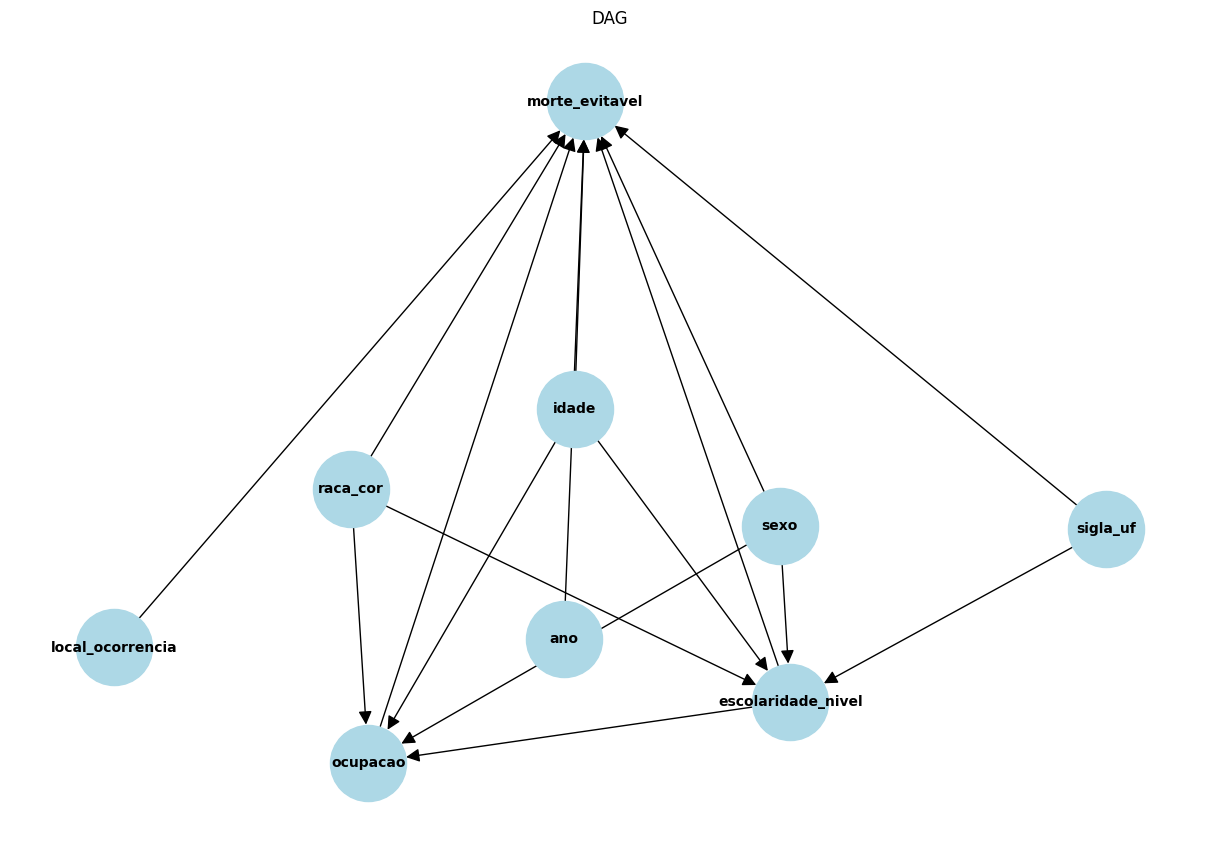

In [216]:
meu_dag = build_and_plot_dag(edges)

# Interpretação do DAG


## Variáveis de confusão

As variáveis:

- idade;
- sexo;
- raça/cor;
- UF;

foram modeladas como possíveis confundidores, pois podem influenciar simultaneamente:

- o nível de escolaridade;
- a probabilidade de morte evitável.

Por exemplo:

- idade influencia diretamente a escolaridade, pois indivíduos mais jovens podem ainda não ter tido tempo suficiente para completar níveis mais altos de educação;
- diferenças regionais podem afetar tanto acesso à educação quanto acesso à saúde;
- desigualdades estruturais associadas a raça/cor podem impactar condições socioeconômicas e mortalidade.


## Independências implícitas

Ao não conectar diretamente algumas variáveis, o DAG implica hipóteses de independência condicional.

Por exemplo, o modelo inicialmente assume independência marginal entre:

- raça/cor e UF;
- idade e sexo;
- idade e raça/cor.

Essas hipóteses serão posteriormente confrontadas com os dados através de testes estatísticos.

# Testando as Implicações do DAG

Uma propriedade importante dos DAGs é que eles implicam independências condicionais observáveis nos dados através do critério de d-separação.

Nesta etapa:

1. extraímos automaticamente as independências implicadas pelo DAG;
2. utilizamos testes de independência do tipo Qui-Quadrado;
3. verificamos se os dados refutam ou não as hipóteses do modelo causal.

O objetivo não é "provar" que o DAG está correto, mas sim avaliar se ele é consistente com os dados observados.

Caso uma independência implicada pelo DAG seja sistematicamente violada nos dados, isso sugere que:

- o DAG pode estar incompleto;
- alguma aresta causal importante foi omitida;
- existem variáveis latentes não modeladas;
- ou existe viés de seleção nos dados.

In [202]:
# Cuidado ao utilizar

def auto_discretize(df, categorical_columns=None, continuous_columns=None, 
                    n_bins=4, bins_method='quantile', rare_threshold=0.05):
    """
    Discretiza automaticamente um DataFrame.
    
    Parâmetros:
        df: DataFrame original.
        categorical_columns: lista de nomes de colunas que já são categóricas (não discretizar, apenas agrupar raras).
        continuous_columns: lista de colunas contínuas a serem discretizadas (se None, detecta automaticamente).
        n_bins: número de bins para discretização de contínuas.
        bins_method: 'quantile' (intervalos com mesma frequência) ou 'uniform' (intervalos iguais).
        rare_threshold: proporção mínima para uma categoria ser mantida; abaixo disso, agrupar em 'outras'.
    
    Retorna:
        df_discretized: DataFrame com todas as colunas convertidas para tipo categórico (strings ou inteiros).
    """
    df_discretized = df.copy()
    
    # Se não especificou colunas contínuas, detectar numeric com muitos valores únicos (>20)
    if continuous_columns is None:
        continuous_columns = []
        for col in df.columns:
            if pd.api.types.is_numeric_dtype(df[col]):
                nunique = df[col].nunique()
                if nunique > 20:   # heurística: se mais de 20 valores únicos, tratar como contínua
                    continuous_columns.append(col)
    
    # Discretizar colunas contínuas
    for col in continuous_columns:
        if col not in df.columns:
            continue
        # Remover missing
        dados = df[col].dropna()
        if dados.nunique() <= 2:
            # Já é praticamente binária, manter como está
            continue
        
        if bins_method == 'quantile':
            # Cria bins com mesma quantidade de observações
            try:
                bins = pd.qcut(dados, q=n_bins, duplicates='drop')
                # Extrair os labels
                labels = [f"{int(b.left)}-{int(b.right)}" for b in bins.cat.categories]
                df_discretized[col] = pd.cut(df[col], bins=bins.cat.categories, labels=labels)
            except ValueError as e:
                # Se falhar (ex: muitos valores repetidos), usa uniform
                bins = np.linspace(dados.min(), dados.max(), n_bins+1)
                labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(n_bins)]
                df_discretized[col] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
        else:  # uniform
            bins = np.linspace(dados.min(), dados.max(), n_bins+1)
            labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(n_bins)]
            df_discretized[col] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    
    # Agrupar categorias raras em colunas categóricas (originais ou resultantes da discretização)
    for col in df_discretized.columns:
        if col in continuous_columns:
            # já tratada
            continue
        # Para colunas que já são categóricas (object, category) ou foram discretizadas para string
        if df_discretized[col].dtype.name in ['object', 'category']:
            freq = df_discretized[col].value_counts(normalize=True)
            rare_cats = freq[freq < rare_threshold].index.tolist()
            if rare_cats:
                # Substituir categorias raras por 'outras'
                df_discretized[col] = df_discretized[col].apply(lambda x: 'outras' if x in rare_cats else x)
        elif pd.api.types.is_numeric_dtype(df_discretized[col]):
            # Se ainda é numérica e não foi tratada (ex: colunas com poucos valores), transformar em string
            df_discretized[col] = df_discretized[col].astype(str)
    
    return df_discretized

In [217]:
# Para testes de independência (Chi-Quadrado), todas as variáveis precisam 
# ser discretas. Vamos garantir que idade seja categórica para o teste.
if 'idade' in df.columns and pd.api.types.is_numeric_dtype(df['idade']):
    df['idade_grupo'] = pd.cut(df['idade'], bins=[0, 25, 45, 60, 75], labels=['jovem', 'adulto', 'meia-idade', 'idoso'])
else:
    df['idade_grupo'] = df['idade']

In [241]:
def colunas_interesse(grafo):
    unique_nodes = list(dict.fromkeys([node for edge in grafo for node in edge]))

    return unique_nodes

In [225]:
# Selecionamos apenas as colunas que vão para o nosso grafo
cols_of_interest = ['idade_grupo', 'raca_cor', 'sexo', 'escolaridade_grupo', 'sigla_uf', 'morte_evitavel', 'ocupacao', 'escolaridade_nivel', 'ano', 'local_ocorrencia']
df_model = df[cols_of_interest].dropna()

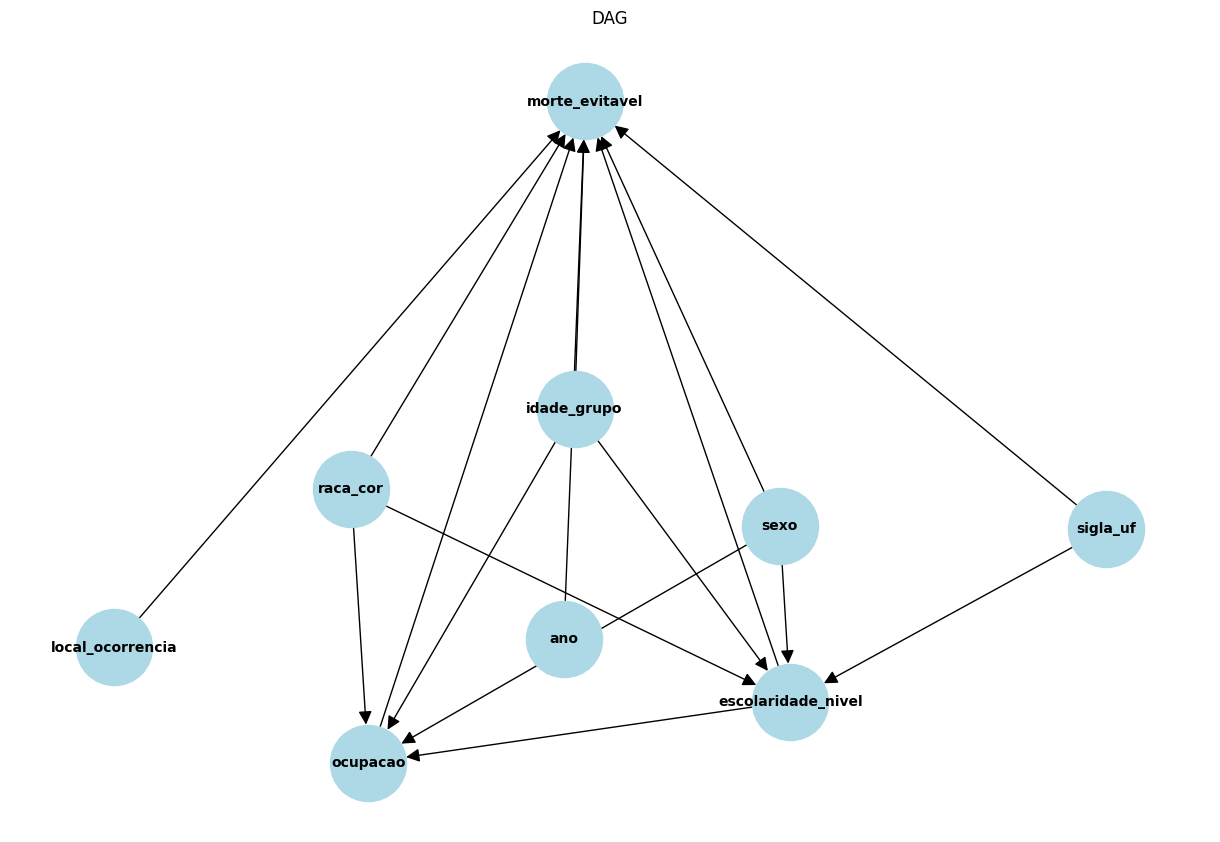

In [226]:
# Exemplo de um DAG inicial
# Assumimos que Sexo não causa UF, Raça não causa Idade, etc. Isso gera d-separações!
meu_dag_edges = [
    ('sigla_uf', 'escolaridade_grupo'), # U -> E
    ('raca_cor', 'escolaridade_grupo'), # R -> E
    ('sexo', 'escolaridade_grupo'), # S -> E
    ('idade_grupo', 'escolaridade_grupo'), # I -> E
    ('sigla_uf', 'morte_evitavel'), # U -> M
    ('raca_cor', 'morte_evitavel'), # R -> M
    ('sexo', 'morte_evitavel'), # S -> M
    ('idade_grupo', 'morte_evitavel'), # I -> M
    ('escolaridade_grupo', 'morte_evitavel') # O efeito causal principal, E -> M
]

meu_dag_edges = [
    ("idade_grupo", "escolaridade_nivel"),
    ("idade_grupo", "ocupacao"),
    ("idade_grupo", "morte_evitavel"),

    ("sexo", "escolaridade_nivel"),
    ("sexo", "ocupacao"),
    ("sexo", "morte_evitavel"),

    ("raca_cor", "escolaridade_nivel"),
    ("raca_cor", "ocupacao"),
    ("raca_cor", "morte_evitavel"),

    ("sigla_uf", "escolaridade_nivel"),
    ("sigla_uf", "morte_evitavel"),

    ("ano", "morte_evitavel"),

    ("escolaridade_nivel", "ocupacao"),
    ("escolaridade_nivel", "morte_evitavel"),

    ("ocupacao", "morte_evitavel"),

    ("local_ocorrencia", "morte_evitavel")
]


meu_dag = build_and_plot_dag(meu_dag_edges)

In [227]:
def test_dag_implications(dag, data, alpha=0.01, subsample_size=1000, n_bootstraps=100, replace=True):
    """
    Busca todas as d-separações (independências) implícitas no DAG e testa nos dados.
    Usa subamostragem (bootstrap) para evitar o viés de N muito grande que reprova tudo.
    """
    independencies = dag.get_independencies()
    assertions = independencies.get_assertions()
    
    if not assertions:
        print("Seu DAG é 'totalmente conectado'. Ele não implica NENHUMA independência.")
        print("DAGs assim não podem ser refutados (mas também são inúteis). Remova algumas arestas lógicas.")
        return
    
    print(f"Encontradas {len(assertions)} d-separações implícitas no DAG.\n")
    print(f"Rodando Chi-Quadrado (alpha={alpha}) com {n_bootstraps} amostras de tamanho {subsample_size}...\n")
    
    # Aplicando Correção de Bonferroni (múltiplas comparações que você anotou da aula!)
    alpha_bonferroni = alpha / len(assertions)
    print(f"Alpha ajustado (Bonferroni) para evitar Falsos Positivos: {alpha_bonferroni:.5f}\n")
    
    results = []
    for assertion in assertions:
        X = list(assertion.event1)[0]
        Y = list(assertion.event2)[0]
        Z = list(assertion.event3)
        
        pass_count = 0
        
        for _ in range(n_bootstraps):
            # Bootstrap: Pegamos uma amostra menor aleatória para o teste
            df_sample = data.sample(n=subsample_size, replace=replace)
            
            # chi_square retorna (chi_stat, p_value, dof)
            # ou boolean=True para retornar se passou no teste (p_value > alpha)
            passed = chi_square(X=X, Y=Y, Z=Z, data=df_sample, 
                                boolean=True, significance_level=alpha_bonferroni)
            if passed:
                pass_count += 1
                
        prob_pass = pass_count / n_bootstraps
        results.append({
            'D-Separacao': f"{X} _|_ {Y} | {Z}",
            'Probabilidade_de_Passar': prob_pass,
            'Refutado?': "SIM" if prob_pass < 0.5 else "NÃO"
        })
        
    df_results = pd.DataFrame(results).sort_values(by='Probabilidade_de_Passar', ascending=False)
    return df_results

In [228]:
resultados_refutacao = test_dag_implications(meu_dag, df_model, alpha=0.05, subsample_size=50000, n_bootstraps=500, replace=False)
display(resultados_refutacao)

Encontradas 20 d-separações implícitas no DAG.

Rodando Chi-Quadrado (alpha=0.05) com 50 amostras de tamanho 2000...

Alpha ajustado (Bonferroni) para evitar Falsos Positivos: 0.00250



,D-Separacao,Probabilidade_de_Passar,Refutado?
0,ano _|_ sexo | [],1.00,NÃO
2,ano _|_ raca_cor | [],1.00,NÃO
4,ano _|_ ocupacao | [],1.00,NÃO
1,ano _|_ sigla_uf | [],0.98,NÃO
3,sexo _|_ sigla_uf | [],0.98,NÃO
10,raca_cor _|_ sexo | [],0.96,NÃO
7,ano _|_ idade_grupo | [],0.92,NÃO
13,ano _|_ local_ocorrencia | [],0.92,NÃO
8,escolaridade_nivel _|_ local_ocorrencia | [],0.52,NÃO
11,idade_grupo _|_ sigla_uf | [],0.36,SIM


## Interpretação dos Resultados

Os testes de independência permitiram avaliar quais hipóteses implícitas no DAG são compatíveis com os dados.

Algumas independências apresentaram alta taxa de aceitação, sugerindo que o DAG é consistente com os dados nesses casos.

Entretanto, algumas independências foram fortemente refutadas, especialmente:

- idade ⟂ sexo;
- idade ⟂ raça/cor;
- raça/cor ⟂ UF.

Esses resultados sugerem que o DAG inicial provavelmente omitiu relações causais importantes.

Por exemplo:

- a distribuição racial varia significativamente entre estados brasileiros;
- a estrutura etária entre indivíduos falecidos pode variar entre sexos;
- o conjunto de dados contém apenas indivíduos mortos, o que introduz viés de seleção.

Essas refutações não invalidam o projeto, mas indicam que o DAG deve ser refinado iterativamente.

# Algoritmo PC (Causal Discovery)

Além de testar um DAG construído manualmente, também utilizamos o algoritmo PC (*Peter-Clark*), uma abordagem de *causal discovery* que tenta inferir a estrutura causal diretamente dos dados.

O algoritmo começa assumindo um grafo totalmente conectado e, em seguida, remove arestas com base em testes de independência condicional (neste trabalho, qui-quadrado). Depois, ele orienta parte das arestas restantes utilizando regras da teoria de grafos causais.

O objetivo não é encontrar o “DAG verdadeiro”, mas identificar estruturas causais compatíveis com as dependências observadas nos dados.

A saída do algoritmo normalmente é um **CPDAG** (*Completed Partially Directed Acyclic Graph*), que representa uma classe de DAGs estatisticamente equivalentes — ou seja, múltiplos grafos capazes de explicar as mesmas independências condicionais.

No contexto do SIM, o algoritmo PC deve ser interpretado com cautela, pois os dados possuem limitações importantes:

- ausência de variáveis latentes relevantes (renda, acesso à saúde, saneamento);
- viés de seleção (a base contém apenas indivíduos que morreram);
- possíveis confundidores não observados;
- dependências regionais fortes representadas de forma simplificada por `sigla_uf`.

Assim, o causal discovery é utilizado principalmente como ferramenta exploratória e de apoio à revisão do DAG teórico inicial.

In [230]:
def run_causal_discovery(data, sample_size=10000):
    """
    Roda o algoritmo PC (Constraint Based) na base de dados para gerar uma 
    Classe de Equivalência (CPDAG).
    """
    print(f"\nRodando Algoritmo PC (Discovery) numa amostra de {sample_size} linhas...")
    
    # 1. Pegamos a amostra e criamos uma cópia independente
    df_sample = data.sample(n=sample_size, random_state=42).copy()
    
    # 2. O SEGREDO: Transformar TUDO em números inteiros (Label Encoding)
    # Isso evita que o pgmpy tente fazer dummies e quebre no meio do caminho.
    le = LabelEncoder()
    for col in df_sample.columns:
        # Convertendo para string primeiro para evitar erros com nulos ocultos
        df_sample[col] = le.fit_transform(df_sample[col].astype(str))
    
    # 3. Inicializa o estimador
    pc = PC(df_sample)
    
    # 4. Estimate forçando o ci_test='chi_square'
    print("Iniciando a estimação de arestas (isso pode demorar uns minutinhos)...")
    estimated_model = pc.estimate(
        return_type='pdag', 
        variant='stable', 
        ci_test='chi_square',    # <-- AQUI: Forçamos o teste correto para dados discretos!
        significance_level=0.01, 
        show_progress=True       
    )
    
    # 5. Plotagem do CPDAG
    plt.figure(figsize=(16, 16))
    pos = nx.spring_layout(estimated_model, seed=42)
    
    nx.draw(estimated_model, pos, with_labels=True, node_size=3500, 
            node_color='lightgreen', font_weight='bold', font_size=10,
            arrowsize=20)
    plt.title("DAG Inferido pelos Dados (Algoritmo PC) - CPDAG")
    plt.show()



Rodando Algoritmo PC (Discovery) numa amostra de 50000 linhas...
Iniciando a estimação de arestas (isso pode demorar uns minutinhos)...


Working for n conditional variables: 5: 100%|█████| 5/5 [03:23<00:00, 40.70s/it]


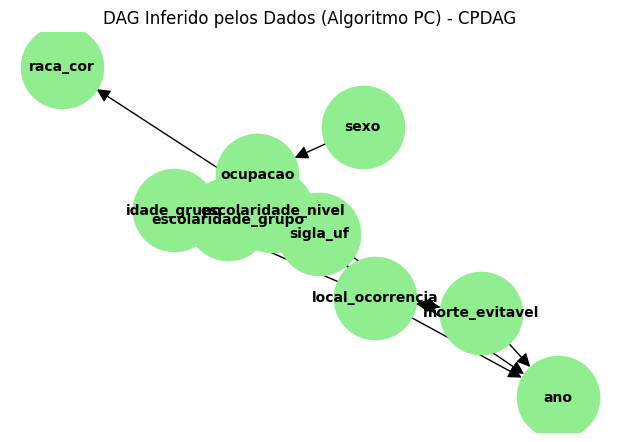

In [231]:
# Atenção: Causal discovery é pesado. Rode em uma amostra.
run_causal_discovery(df_model, sample_size=50000)

- O PC frequentemente NÃO consegue orientar causalidade. Por isso as setas bidirecionais 

## Bootstrap Structural Discovery

Como algoritmos de causal discovery podem ser instáveis dependendo da amostra utilizada, executamos o algoritmo PC múltiplas vezes utilizando bootstrap.

A ideia é verificar quais arestas aparecem consistentemente entre diferentes subamostras dos dados. A frequência de ocorrência de cada aresta foi utilizada como medida de estabilidade estrutural.

Entretanto, os resultados devem ser interpretados com cautela:

- o algoritmo PC retorna uma CPDAG/PDAG, e não necessariamente um DAG completamente orientado;
- algumas orientações podem variar entre execuções devido à equivalência estatística entre estruturas;
- relações temporalmente impossíveis podem surgir por dependência estatística ou viés de seleção;
- a base contém apenas indivíduos que morreram, o que pode introduzir collider bias;
- variáveis latentes importantes (renda, saneamento, acesso à saúde) não estão observadas.

Assim, o causal discovery foi utilizado como ferramenta exploratória para sugerir dependências estruturais e auxiliar na revisão do DAG teórico inicial, e não como prova definitiva de causalidade.

Iniciando Discovery Estabilizado: 50 iterações de 5000 amostras.

Executando Bootstrap 1/50...
Executando Bootstrap 2/50...
Executando Bootstrap 3/50...
Executando Bootstrap 4/50...
Executando Bootstrap 5/50...
Executando Bootstrap 6/50...
Executando Bootstrap 7/50...
Executando Bootstrap 8/50...
Executando Bootstrap 9/50...
Executando Bootstrap 10/50...
Executando Bootstrap 11/50...
Executando Bootstrap 12/50...
Executando Bootstrap 13/50...
Executando Bootstrap 14/50...
Executando Bootstrap 15/50...
Executando Bootstrap 16/50...
Executando Bootstrap 17/50...
Executando Bootstrap 18/50...
Executando Bootstrap 19/50...
Executando Bootstrap 20/50...
Executando Bootstrap 21/50...
Executando Bootstrap 22/50...
Executando Bootstrap 23/50...
Executando Bootstrap 24/50...
Executando Bootstrap 25/50...
Executando Bootstrap 26/50...
Executando Bootstrap 27/50...
Executando Bootstrap 28/50...
Executando Bootstrap 29/50...
Executando Bootstrap 30/50...
Executando Bootstrap 31/50...
Executando Bo

,Aresta,Confianca (%)
6,sexo -> ocupacao,94.0
13,raca_cor -> sigla_uf,84.0
1,escolaridade_nivel -> escolaridade_grupo,82.0
0,escolaridade_grupo -> escolaridade_nivel,70.0
7,ocupacao -> idade_grupo,48.0
4,idade_grupo -> local_ocorrencia,44.0
3,sigla_uf -> escolaridade_nivel,40.0
18,ocupacao -> sexo,34.0
8,ano -> morte_evitavel,34.0
16,ano -> escolaridade_nivel,30.0


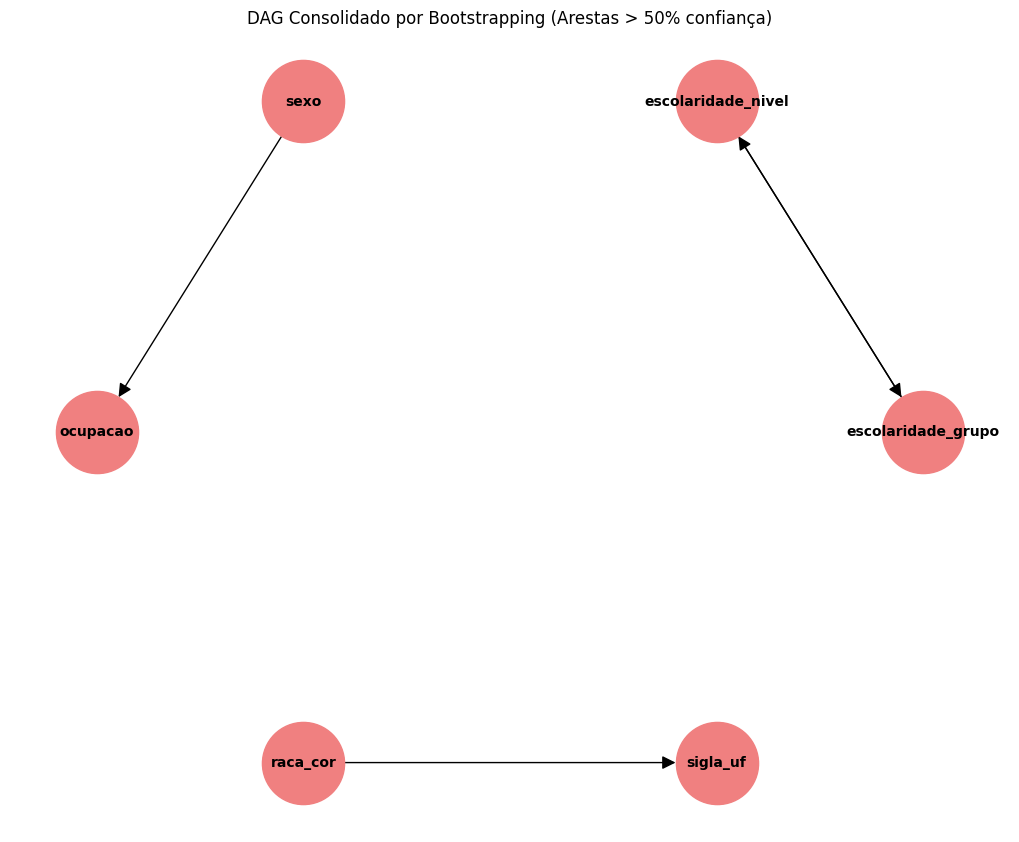

In [234]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pgmpy.estimators import PC
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

def run_stable_causal_discovery(data, n_bootstraps=10, sample_size=5000):
    """
    Roda o algoritmo PC MÚLTIPLAS VEZES para encontrar arestas consistentes.
    Retorna estatísticas sobre a confiança de cada aresta.
    """
    print(f"Iniciando Discovery Estabilizado: {n_bootstraps} iterações de {sample_size} amostras.\n")
    
    edge_counts = defaultdict(int)
    
    # Label Encoding de toda a base de uma vez para manter a consistência
    le_dict = {}
    df_encoded = data.copy()
    for col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le

    for i in range(n_bootstraps):
        print(f"Executando Bootstrap {i+1}/{n_bootstraps}...")
        # Cada bootstrap pega uma amostra aleatória DIFERENTE
        df_sample = df_encoded.sample(n=sample_size, replace=True)
        
        pc = PC(df_sample)
        
        # Como o processo é longo, removemos a barra de progresso (show_progress=False)
        estimated_model = pc.estimate(
            return_type='pdag', 
            variant='stable', 
            ci_test='chi_square',
            significance_level=0.01, 
            show_progress=False
        )
        
        # Extraindo as arestas deste grafo específico
        for u, v in estimated_model.edges():
            # Arestas no PDAG podem ser direcionadas (U->V) ou não direcionadas (U-V)
            # Salvamos como tupla para contar a frequência
            edge_counts[(u, v)] += 1

    # Compilando os resultados estatísticos
    print("\n=== ESTATÍSTICAS DE ARESTAS (CONFIANÇA) ===")
    results = []
    for edge, count in edge_counts.items():
        confidence = (count / n_bootstraps) * 100
        results.append({
            'Aresta': f"{edge[0]} -> {edge[1]}", # Nota: no PDAG a seta pode ser bidirecional se aparecer também B->A
            'Confianca (%)': confidence
        })
        
    df_results = pd.DataFrame(results).sort_values(by='Confianca (%)', ascending=False)
    display(df_results)
    
    # Vamos gerar o grafo final contendo apenas arestas "fortes" (ex: confiança > 50%)
    strong_edges = [edge for edge, count in edge_counts.items() if (count / n_bootstraps) > 0.5]
    
    final_pdag = nx.DiGraph()
    final_pdag.add_edges_from(strong_edges)
    
    plt.figure(figsize=(10, 8))
    pos = nx.circular_layout(final_pdag) # Layout circular costuma espalhar melhor
    nx.draw(final_pdag, pos, with_labels=True, node_size=3500, 
            node_color='lightcoral', font_weight='bold', font_size=10,
            arrowsize=20)
    plt.title("DAG Consolidado por Bootstrapping (Arestas > 50% confiança)")
    plt.show()

# Ajuste n_bootstraps e sample_size conforme a capacidade do seu computador
run_stable_causal_discovery(df_model, n_bootstraps=50, sample_size=10000)

- Lembrando que o resultado exploratório de causal discovery é sujeito a instabilidade e equivalência estatística. Se houver um confundidor não medido (supondo algo como a "Renda" no nosso projeto), o algoritmo PC pode desenhar uma seta errada (espuria) entre duas variáveis apenas porque ambas são afetadas por essa suposta renda invisível.


# Novas iterações para melhora do grafo

- Da iteração passada, modificamos o grafo anterior com as novas informações 

In [251]:
# O NOVO DAG REVISADO

meu_novo_dag_edges = [
    # 1. Determinantes Estruturais de Base (A base da desigualdade)
    # ("raca_cor", "sigla_uf"),       # Validado pelo PC (Demografia regional)
    ("raca_cor", "idade_grupo"),    # Corrige refutação (Expectativa de vida)
    ("sexo", "idade_grupo"),        # Corrige refutação (Mulheres vivem mais)
    ("ano", "escolaridade_grupo"),  # Corrige refutação (Melhoria educacional no tempo)

    # 2. O que causa a Escolaridade (Tratamento)
    ("idade_grupo", "escolaridade_grupo"),
    ("sexo", "escolaridade_grupo"),
    ("raca_cor", "escolaridade_grupo"),
    ("sigla_uf", "escolaridade_grupo"),

    # 3. O que causa a Ocupação (Mediador 1)
    ("idade_grupo", "ocupacao"),
    ("sexo", "ocupacao"),           # Validado pelo PC
    ("raca_cor", "ocupacao"),
    ("escolaridade_grupo", "ocupacao"),
    ("sigla_uf", "ocupacao"),       # O mercado de trabalho varia por estado?

    # 4. O que causa o Local de Ocorrência (Hospital, Rua, Casa) (Mediador 2)
    ("sigla_uf", "local_ocorrencia"),    # Infraestrutura do estado (Validado pelo PC) ? 
    ("idade_grupo", "local_ocorrencia"), # Corrige refutação (ex: idosos morrerem no hospital)
    ("sexo", "local_ocorrencia"),        # Corrige refutação (ex: homens morrerem mais em vias públicas) ?
    ("ocupacao", "local_ocorrencia"),    # ex: Acidentes de trabalho vs. aposentadoria

    # 5. O que causa a Morte Evitável (Desfecho)
    ("idade_grupo", "morte_evitavel"),
    ("sexo", "morte_evitavel"),
    ("raca_cor", "morte_evitavel"),
    ("sigla_uf", "morte_evitavel"),
    ("ano", "morte_evitavel"),
    
    # Os caminhos de interesse
    ("escolaridade_grupo", "morte_evitavel"), # O Efeito Direto
    ("ocupacao", "morte_evitavel"),           # O Efeito Indireto via emprego
    ("local_ocorrencia", "morte_evitavel")    # O Efeito Indireto via acesso a hospitais
]


In [259]:
unique_nodes = list(dict.fromkeys([node for edge in meu_novo_dag_edges for node in edge]))
print(unique_nodes)

['raca_cor', 'idade_grupo', 'sexo', 'ano', 'escolaridade_grupo', 'sigla_uf', 'ocupacao', 'local_ocorrencia', 'morte_evitavel']


In [262]:
df_model = df_model[cols_of_interest].dropna()
df_model = df_model.drop('escolaridade_nivel', axis=1)

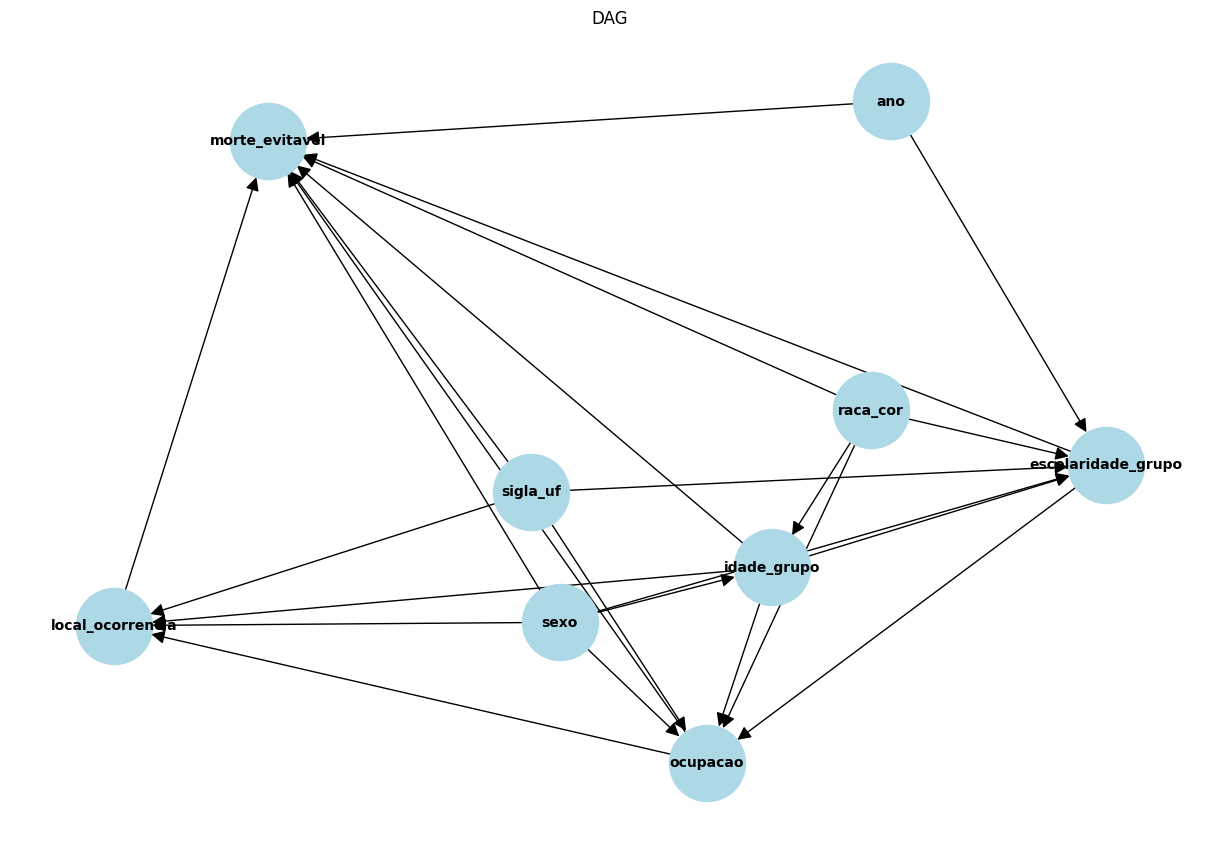

In [253]:
# Construindo e plotando
meu_novo_dag = build_and_plot_dag(meu_novo_dag_edges)

In [254]:
# Rode a refutação
novos_resultados = test_dag_implications(meu_novo_dag, df_model, alpha=0.05, subsample_size=20000, n_bootstraps=100)
display(novos_resultados)

Encontradas 12 d-separações implícitas no DAG.

Rodando Chi-Quadrado (alpha=0.05) com 100 amostras de tamanho 20000...

Alpha ajustado (Bonferroni) para evitar Falsos Positivos: 0.00417



,D-Separacao,Probabilidade_de_Passar,Refutado?
8,local_ocorrencia _|_ raca_cor | ['idade_grupo'...,1.00,NÃO
9,escolaridade_grupo _|_ local_ocorrencia | ['id...,1.00,NÃO
4,ano _|_ sexo | [],0.97,NÃO
11,ano _|_ raca_cor | [],0.30,SIM
1,sexo _|_ sigla_uf | [],0.15,SIM
10,"ano _|_ local_ocorrencia | ['idade_grupo', 'oc...",0.14,SIM
6,ano _|_ sigla_uf | [],0.02,SIM
0,"ano _|_ ocupacao | ['sigla_uf', 'sexo', 'idade...",0.00,SIM
2,idade_grupo _|_ sigla_uf | [],0.00,SIM
3,ano _|_ idade_grupo | [],0.00,SIM


- Percebemos que as independências que existiam na primeira iteração (ex: ano _|_ raca_cor), já não são inferidas no grafo na segunda iteração. Indicando que o DAG ainda não é suficientemente robusto

Iniciando Discovery Estabilizado: 10 iterações de 10000 amostras.

Executando Bootstrap 1/10...
Executando Bootstrap 2/10...
Executando Bootstrap 3/10...
Executando Bootstrap 4/10...
Executando Bootstrap 5/10...
Executando Bootstrap 6/10...
Executando Bootstrap 7/10...
Executando Bootstrap 8/10...
Executando Bootstrap 9/10...
Executando Bootstrap 10/10...

=== ESTATÍSTICAS DE ARESTAS (CONFIANÇA) ===


,Aresta,Confianca (%)
4,escolaridade_grupo -> escolaridade_nivel,90.0
7,raca_cor -> sigla_uf,90.0
9,escolaridade_nivel -> escolaridade_grupo,90.0
2,sexo -> ocupacao,60.0
5,idade_grupo -> local_ocorrencia,50.0
0,sigla_uf -> escolaridade_nivel,40.0
12,ocupacao -> sexo,40.0
6,idade_grupo -> ocupacao,40.0
15,sigla_uf -> ocupacao,40.0
17,ocupacao -> idade_grupo,30.0


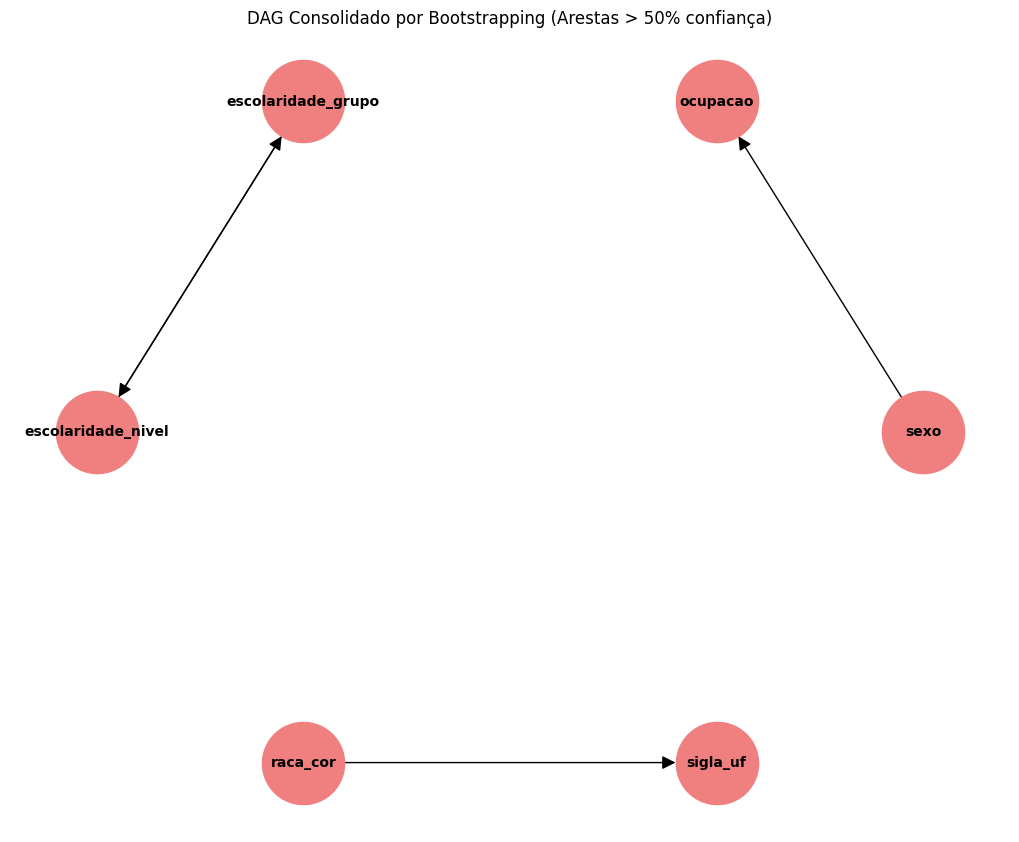

In [255]:
run_stable_causal_discovery(df_model, n_bootstraps=10, sample_size=10000)

# Limitações Metodológicas

## Viés de seleção

O SIM contém apenas indivíduos que foram a óbito.

Portanto, o estudo não representa a população geral, mas sim a distribuição de características entre indivíduos falecidos.

Isso implica possível viés de seleção (`selection bias`), já que diversas relações observadas podem ser consequência do condicionamento implícito no evento de morte.

## Ausência de variáveis latentes

Diversos fatores potencialmente importantes não estão presentes nos dados, como:

- renda;
- acesso longitudinal à saúde;
- saneamento;
- hábitos de vida;
- comorbidades;
- contexto familiar.

A ausência dessas variáveis pode gerar confundimento residual.

## Limitações dos testes de independência

Com grandes volumes de dados, testes estatísticos podem detectar dependências muito pequenas como estatisticamente significativas.

Para reduzir esse problema, utilizamos:

- subamostragem;
- múltiplos testes;
- correção de Bonferroni.

Mesmo assim, significância estatística não implica necessariamente relevância causal.

## Limitações do causal discovery

Algoritmos como PC e GES não recuperam automaticamente o "DAG verdadeiro".

Os grafos inferidos dependem fortemente:

- das hipóteses do algoritmo;
- dos testes estatísticos utilizados;
- da discretização das variáveis;
- da presença de confundidores latentes.

Por isso, os resultados de causal discovery foram utilizados apenas como apoio exploratório para revisão do DAG teórico.